# transformar audios a espectrogramas

In [1]:
!pip install -q librosa
!pip install -q opencv-python
print("listo!")

listo!


### leer metadatos y audios

In [2]:
import os
import shutil
import pandas as pd

# rutas de entrada y salida
ESC50_META = "meta/esc50.csv"        # ruta al archivo de etiquetas
ESC50_AUDIO = "audio/"               # carpeta donde están los .wav originales
OUTPUT_DIR = "ESC-50-organized/"     # carpeta destino donde se organizarán

# leer metadatos
meta = pd.read_csv(ESC50_META)

# crear carpeta base de salida si no existe
os.makedirs(OUTPUT_DIR, exist_ok=True)

# recorrer cada fila del CSV
for _, row in meta.iterrows():
    filename = row["filename"]
    category = row["category"]

    # carpeta destino segun categoria
    class_dir = os.path.join(OUTPUT_DIR, category)
    os.makedirs(class_dir, exist_ok=True)

    #ruta origen y destino
    src = os.path.join(ESC50_AUDIO, filename)
    dst = os.path.join(class_dir, filename)

    #copiar archivo si existe
    if os.path.exists(src):
        shutil.copy(src, dst)
    else:
        print(f"No se encontró: {src}")

print("Organización completada.")


Organización completada.


### hacer subcarpetas por categoria y hacer espectrogramas a 3 canales RGB de 224x224

In [3]:
import os

input_dir = "ESC-50-organized"
output_dir = "spectrograms_224"
os.makedirs(output_dir, exist_ok=True)

files = os.listdir(input_dir)


In [4]:
import os
import librosa
import numpy as np
import cv2

input_dir = "ESC-50-organized"
output_dir = "spectrograms_224"
os.makedirs(output_dir, exist_ok=True)

#procesar por clase (subcarpetas) y por archivo .wav dentro de cada una
for class_name in sorted(os.listdir(input_dir)):
    class_in = os.path.join(input_dir, class_name)
    if not os.path.isdir(class_in):
        continue
    class_out = os.path.join(output_dir, class_name)
    os.makedirs(class_out, exist_ok=True)

    for file in sorted(os.listdir(class_in)):
        if not file.lower().endswith(".wav"):
            continue

        src_path = os.path.join(class_in, file)
        try:
            y, sr = librosa.load(src_path, sr=22050)
        except Exception as e:
            print(f"Error loading {src_path}: {e}")
            continue

        #generar Mel-spectrograma
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
        S_dB = librosa.power_to_db(S, ref=np.max)

        #normalizar a [0, 255]
        img = (S_dB - S_dB.min()) / (S_dB.max() - S_dB.min() + 1e-8)
        img = np.uint8(255 * img)

        # aplicar mapa de color (magma) y redimensionar a 224x224
        img_color = cv2.applyColorMap(img, cv2.COLORMAP_MAGMA)
        img_resized = cv2.resize(img_color, (224, 224))

        # guardar imagen RGB dentro de la carpeta de la clase
        out_name = file.replace(".wav", ".png")
        out_path = os.path.join(class_out, out_name)
        cv2.imwrite(out_path, cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB))

print("Espectrogramas guardados en:", output_dir)

Espectrogramas guardados en: spectrograms_224


### dividir en train, val, test con proporciones 70%, 15%, 15% manteniendo distribucion de clases (se mueven los .png de las subcarpetas, no se copian)

In [ ]:
import os
import random
import shutil

random.seed(42)

base_dir = "spectrograms_224"
output_dir = "spectrograms_split_224"
splits = ["train", "val", "test"]
ratios = [0.7, 0.15, 0.15]
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tiff")

#crear carpetas top-level
for split in splits:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

def _split_and_transfer(file_list, src_dir, class_name, move=True):
    random.shuffle(file_list)
    n_total = len(file_list)
    n_train = int(n_total * ratios[0])
    n_val = int(n_total * ratios[1])
    train_files = file_list[:n_train]
    val_files = file_list[n_train:n_train + n_val]
    test_files = file_list[n_train + n_val:]
    counts = {}
    for split, files in zip(splits, [train_files, val_files, test_files]):
        dst_dir = os.path.join(output_dir, split, class_name)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in files:
            src = os.path.join(src_dir, fname)
            dst = os.path.join(dst_dir, fname)
            try:
                if move:
                    shutil.move(src, dst)
                else:
                    shutil.copy2(src, dst)
            except Exception as e:
                print(f"Error transferring {src} -> {dst}: {e}")
        counts[split] = len(files)
    return n_total, counts["train"], counts["val"], counts["test"]

#detectar si hay subcarpetas por clase
entries = [e for e in sorted(os.listdir(base_dir)) if not e.startswith(".")]
has_class_dirs = any(os.path.isdir(os.path.join(base_dir, e)) for e in entries)

summary = []
if has_class_dirs:
    for class_name in entries:
        class_path = os.path.join(base_dir, class_name)
        if not os.path.isdir(class_path):
            continue
        images = [f for f in sorted(os.listdir(class_path)) if f.lower().endswith(IMG_EXTS)]
        if not images:
            continue
        totals = _split_and_transfer(images, class_path, class_name, move=True)  # mover para evitar duplicados
        summary.append((class_name,) + totals)
else:
    images = [f for f in sorted(os.listdir(base_dir)) if f.lower().endswith(IMG_EXTS)]
    if images:
        totals = _split_and_transfer(images, base_dir, "class0", move=True)
        summary.append(("class0",) + totals)

print("Resumen por clase (class, total, n_train, n_val, n_test):")
for row in summary:
    print(row)

#comprobar si hay duplicados entre splits (por nombre de archivo) (ojala que no)
from pathlib import Path
train_files = {p.name for p in Path(output_dir, "train").rglob("*") if p.is_file()}
val_files = {p.name for p in Path(output_dir, "val").rglob("*") if p.is_file()}
test_files = {p.name for p in Path(output_dir, "test").rglob("*") if p.is_file()}
print("duplicates trainval:", len(train_files & val_files))
print("duplicates traintest:", len(train_files & test_files))
print("duplicates valtest:", len(val_files & test_files))

print("División completada y guardada en:", output_dir)

Resumen por clase (class, total, n_train, n_val, n_test):
('airplane', 40, 28, 6, 6)
('breathing', 40, 28, 6, 6)
('brushing_teeth', 40, 28, 6, 6)
('can_opening', 40, 28, 6, 6)
('car_horn', 40, 28, 6, 6)
('cat', 40, 28, 6, 6)
('chainsaw', 40, 28, 6, 6)
('chirping_birds', 40, 28, 6, 6)
('church_bells', 40, 28, 6, 6)
('clapping', 40, 28, 6, 6)
('clock_alarm', 40, 28, 6, 6)
('clock_tick', 40, 28, 6, 6)
('coughing', 40, 28, 6, 6)
('cow', 40, 28, 6, 6)
('crackling_fire', 40, 28, 6, 6)
('crickets', 40, 28, 6, 6)
('crow', 40, 28, 6, 6)
('crying_baby', 40, 28, 6, 6)
('dog', 40, 28, 6, 6)
('door_wood_creaks', 40, 28, 6, 6)
('door_wood_knock', 40, 28, 6, 6)
('drinking_sipping', 40, 28, 6, 6)
('engine', 40, 28, 6, 6)
('fireworks', 40, 28, 6, 6)
('footsteps', 40, 28, 6, 6)
('frog', 40, 28, 6, 6)
('glass_breaking', 40, 28, 6, 6)
('hand_saw', 40, 28, 6, 6)
('helicopter', 40, 28, 6, 6)
('hen', 40, 28, 6, 6)
('insects', 40, 28, 6, 6)
('keyboard_typing', 40, 28, 6, 6)
('laughing', 40, 28, 6, 6)
('mouse_

# Modelo A
## Modelo A base

In [6]:
!pip install -q torchvision

In [7]:

import os
import random
import argparse
import numpy as np

import torch #solo usamos torch como dice la instruccion y lo de sklearn es para metricas asi que estamos bien
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, classification_report

# --------------------------
# Utilities: reproducibility de random
# --------------------------
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# --------------------------
# LeNet-5 (manual)
# --------------------------
class LeNet5Base(nn.Module):
    def __init__(self, num_classes=50):
        super(LeNet5Base, self).__init__()
        #input: 3 x 224 x 224
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=2)   # -> 6 x 224 x 224
        self.pool1 = nn.AvgPool2d(2, 2)                                    # -> 6 x 112 x 112

        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)                       # -> 16 x 108 x 108
        self.pool2 = nn.AvgPool2d(2, 2)                                    # -> 16 x 54 x 54

        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)                     # -> 120 x 50 x 50

        #reduce dims espaciales para evitar gran FC
        self.gap = nn.AdaptiveAvgPool2d((5, 5))                            # -> 120 x 5 x 5
        self.fc1 = nn.Linear(120 * 5 * 5, 84)
        self.fc2 = nn.Linear(84, num_classes)

        # Weight init 
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu') #relu como funcion de activacion
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = self.gap(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [8]:
# --------------------------
# Training / validation / test
# --------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

In [9]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, labels in loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / total
    acc = correct / total
    return avg_loss, acc

@torch.no_grad()
def test_and_report(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []

    for imgs, labels in loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.numpy().tolist())

    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)
    acc = np.sum(np.diag(cm)) / np.sum(cm)
    return cm, report, acc

In [10]:
# --------------------------
# Helpers: data transforms
# --------------------------
def get_transforms(augmented=False):
    # Base transforms (for val/test)
    base = [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]

    if not augmented:
        return transforms.Compose(base)

    # Augmented transforms for training (image-space augmentations)
    aug = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomApply([
            transforms.RandomRotation(10),              # small freq/time shift
            transforms.RandomHorizontalFlip(p=0.5),    # reflect time axis (if valid)
            transforms.ColorJitter(brightness=0.15, contrast=0.15),
            transforms.RandomResizedCrop(224, scale=(0.9, 1.0)),
        ], p=0.8),
        transforms.ToTensor()
    ])
    return aug


In [ ]:
# --------------------------
# Function to run one experiment (one run) (augmented = False)
# --------------------------
def run_experiment(data_dir, output_dir, run_name, num_classes=50, epochs=20, batch_size=32,
                   lr=1e-3, weight_decay=1e-5, augmented=False, seed=42, device='cuda'):
    set_seed(seed)
    device = torch.device(device if torch.cuda.is_available() and device == 'cuda' else 'cpu')
    print(f"[Run {run_name}] Device: {device} | Augmented: {augmented} | Seed: {seed}")

    # Paths (expects splitted folder: train/ val/ test/)
    train_dir = os.path.join(data_dir, "train")
    val_dir   = os.path.join(data_dir, "val")
    test_dir  = os.path.join(data_dir, "test")

    # Transforms
    transform_train = get_transforms(augmented=augmented)
    transform_eval = get_transforms(augmented=False)

    train_dataset = datasets.ImageFolder(train_dir, transform=transform_train)
    val_dataset = datasets.ImageFolder(val_dir, transform=transform_eval)
    test_dataset = datasets.ImageFolder(test_dir, transform=transform_eval)

    class_names = [c[0] for c in sorted(train_dataset.class_to_idx.items(), key=lambda x: x[1])]
    print(f"[Run {run_name}] Classes: {len(class_names)} | Train size: {len(train_dataset)} | Val size: {len(val_dataset)} | Test size: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    # Model, loss, optimizer, scheduler
    model = LeNet5Base(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    

    # ReduceLROnPlateau signature puede variar entre versiones de torch.
    # Intentar con verbose=True y si da TypeError, crear sin ese argumento.
    try:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3, verbose=True
        )
    except TypeError:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=3
        )


    best_val_loss = float('inf')
    best_epoch = -1
    best_state = None


    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # Logging
        print(f"[{run_name}] Epoch {epoch}/{epochs} | Train loss: {train_loss:.4f} acc: {train_acc:.4f} | Val loss: {val_loss:.4f} acc: {val_acc:.4f}")
        
        # Save best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss": val_loss,
                "val_acc": val_acc,
                "epoch": epoch,
                "class_to_idx": train_dataset.class_to_idx
            }
            # Save checkpoint
            os.makedirs(output_dir, exist_ok=True)
            ckpt_path = os.path.join(output_dir, f"best_{run_name}.pth")
            torch.save(best_state, ckpt_path)

    print(f"[{run_name}] Best val loss: {best_val_loss:.4f} at epoch {best_epoch}")

    # Load best for final test
    if best_state is not None:
        model.load_state_dict(best_state["model_state"])

    cm, report, test_acc = test_and_report(model, test_loader, device, class_names)
    #print(f"[{run_name}] Test acc: {test_acc:.4f}")
    #print(f"[{run_name}] Classification report:\n{report}")

    # Save final artifacts
    final_dir = os.path.join(output_dir, f"final_{run_name}")
    os.makedirs(final_dir, exist_ok=True)
    torch.save(model.state_dict(), os.path.join(final_dir, "model_final.pth"))
    np.save(os.path.join(final_dir, "confusion_matrix.npy"), cm)
    with open(os.path.join(final_dir, "classification_report.txt"), "w") as f:
        f.write(report)


    return {
        "run_name": run_name,
        "best_val_loss": best_val_loss,
        "best_epoch": best_epoch,
        "test_acc": test_acc,
        "report": report,
        "confusion_matrix": cm,
        "history": history
    }

In [23]:
# --------------------------
# CLI: run multiple experiments (>=5 runs)
# --------------------------
def multiple_experiments_modelA(argv=None):
    parser = argparse.ArgumentParser()
    parser.add_argument("--data_dir", type=str, default="spectrograms_split_224", help="Folder with train/val/test subfolders")
    parser.add_argument("--output_dir", type=str, default="results_lenet_a", help="Where to save checkpoints and outputs")
    parser.add_argument("--num_classes", type=int, default=50)
    parser.add_argument("--epochs", type=int, default=1000)
    parser.add_argument("--batch_size", type=int, default=32)
    parser.add_argument("--lr", type=float, default=1e-3)
    parser.add_argument("--weight_decay", type=float, default=1e-5)
    parser.add_argument("--runs", type=int, default=5, help="Number of runs (>=5 recommended)")
    parser.add_argument("--device", type=str, default="cuda", help="cuda or cpu")
    parser.add_argument("--seed_start", type=int, default=42, help="starting seed for runs (will increment)")

    
    import sys
    if argv is not None:
        args = parser.parse_args(argv)
    else:
        if 'ipykernel' in sys.modules:
            args, _ = parser.parse_known_args()
        else:
            args = parser.parse_args()

    os.makedirs(args.output_dir, exist_ok=True)

    aggregate_results = []
    for i in range(args.runs):
        seed = args.seed_start + i
        run_name = f"lenet_a_base_run{i+1}_s{seed}"
        out = run_experiment(
            data_dir=args.data_dir,
            output_dir=args.output_dir,
            run_name=run_name,
            num_classes=args.num_classes,
            epochs=args.epochs,
            batch_size=args.batch_size,
            lr=args.lr,
            weight_decay=args.weight_decay,
            seed=seed,
            device=args.device
        )
        aggregate_results.append(out)

    # summarize runs
    aggregate_results = sorted(aggregate_results, key=lambda x: x["test_acc"], reverse=True)
    best = aggregate_results[0]
    summary_path = os.path.join(args.output_dir, f"summary_base.txt")
    with open(summary_path, "w") as f:
        f.write("Summary of runs (sorted by test_acc desc):\n\n")
        for r in aggregate_results:
            f.write(f"{r['run_name']}: test_acc={r['test_acc']:.4f}, best_val_loss={r['best_val_loss']:.4f}, best_epoch={r['best_epoch']}\n")
        f.write("\nBest overall:\n")
        f.write(str(best))

    print("All runs finished. Summary saved to:", summary_path)

    return aggregate_results

results = multiple_experiments_modelA()

[Run lenet_a_base_run1_s42] Device: cpu | Augmented: False | Seed: 42
[Run lenet_a_base_run1_s42] Classes: 50 | Train size: 1400 | Val size: 300 | Test size: 300


c:\Users\mauri\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyboardInterrupt: 

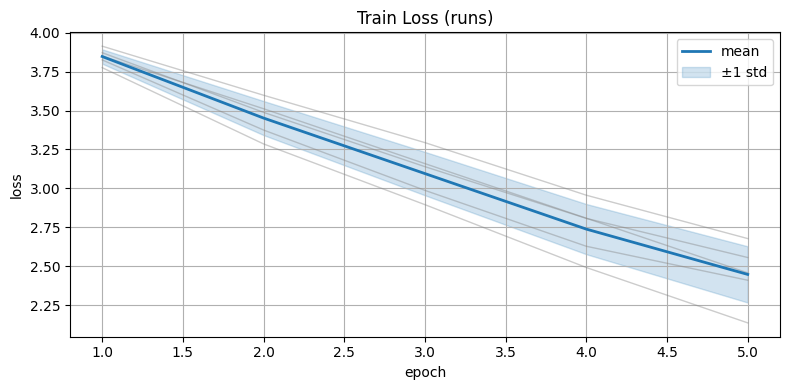

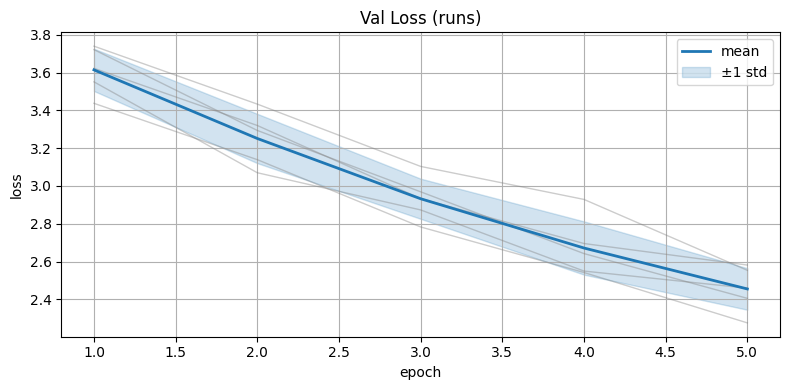

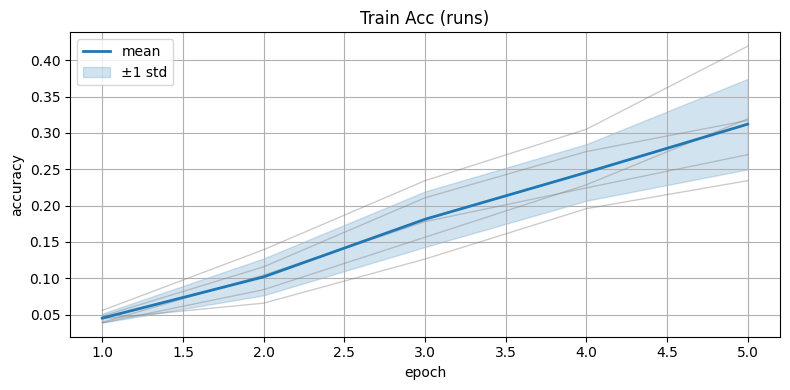

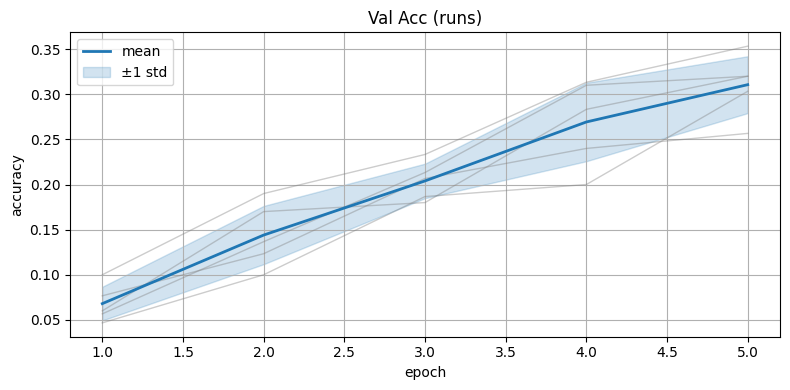

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import os

out_dir = "results_plots"
os.makedirs(out_dir, exist_ok=True)

# results debe estar en memoria (lista de dicts con 'history')
# cada history: {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
histories = [r['history'] for r in results]
n_runs = len(histories)
epochs = len(histories[0]['train_loss'])

# convertir a arrays (shape: n_runs x epochs)
train_loss = np.array([h['train_loss'] for h in histories])
val_loss   = np.array([h['val_loss'] for h in histories])
train_acc  = np.array([h['train_acc'] for h in histories])
val_acc    = np.array([h['val_acc'] for h in histories])
x = np.arange(1, epochs+1)

def plot_with_mean(ax, arr, title, ylabel, filename):
    # plot each run en gris claro
    for row in arr:
        ax.plot(x, row, color='gray', alpha=0.4, linewidth=1)
    # mean y std
    mean = arr.mean(axis=0)
    std  = arr.std(axis=0)
    ax.plot(x, mean, color='tab:blue', linewidth=2, label='mean')
    ax.fill_between(x, mean-std, mean+std, color='tab:blue', alpha=0.2, label='±1 std')
    ax.set_title(title)
    ax.set_xlabel('epoch')
    ax.set_ylabel(ylabel)
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, filename), dpi=150)

# Loss figure (train + val)
fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, train_loss, "Train Loss (runs)", "loss", "train_loss.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, val_loss, "Val Loss (runs)", "loss", "val_loss.png")
plt.show()

# Acc figure
fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, train_acc, "Train Acc (runs)", "accuracy", "train_acc.png")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
plot_with_mean(ax, val_acc, "Val Acc (runs)", "accuracy", "val_acc.png")
plt.show()

## Model A Aumentado

In [20]:
res_aug = run_experiment(
    data_dir="spectrograms_split_224",
    output_dir="results_lenet_a_aug",
    run_name="lenet_a_aug_run1",
    num_classes=50,
    epochs=5,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-5,
    augmented=True,   
    seed=42,
    device="cuda"   
)
print("Test acc:", res_aug["test_acc"])


[Run lenet_a_aug_run1] Device: cpu | Augmented: True | Seed: 42
[Run lenet_a_aug_run1] Classes: 50 | Train size: 1400 | Val size: 300 | Test size: 300


c:\Users\mauri\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[lenet_a_aug_run1] Epoch 1/5 | Train loss: 3.8373 acc: 0.0386 | Val loss: 3.7056 acc: 0.0567
[lenet_a_aug_run1] Epoch 2/5 | Train loss: 3.5771 acc: 0.0721 | Val loss: 3.3322 acc: 0.1067
[lenet_a_aug_run1] Epoch 3/5 | Train loss: 3.2297 acc: 0.1157 | Val loss: 3.0629 acc: 0.1433
[lenet_a_aug_run1] Epoch 4/5 | Train loss: 2.9425 acc: 0.1757 | Val loss: 2.8094 acc: 0.2133
[lenet_a_aug_run1] Epoch 5/5 | Train loss: 2.7026 acc: 0.2314 | Val loss: 2.4428 acc: 0.3200
[lenet_a_aug_run1] Best val loss: 2.4428 at epoch 5
[lenet_a_aug_run1] Test acc: 0.2867
[lenet_a_aug_run1] Classification report:
                  precision    recall  f1-score   support

        airplane     0.2000    0.6667    0.3077         6
       breathing     0.5000    0.1667    0.2500         6
  brushing_teeth     1.0000    0.1667    0.2857         6
     can_opening     0.4545    0.8333    0.5882         6
        car_horn     0.0000    0.0000    0.0000         6
             cat     0.5000    0.3333    0.4000         

In [ ]:
aggregate_aug = []
n_runs = 5
for i in range(n_runs):
    seed = 42 + i
    run_name = f"lenet_a_aug_run{i+1}_s{seed}"
    out = run_experiment(
        data_dir="spectrograms_split_224",
        output_dir="results_lenet_a_aug",
        run_name=run_name,
        num_classes=50,
        epochs=1000,
        batch_size=32,
        lr=1e-3,
        weight_decay=1e-5,
        augmented=True,
        seed=seed,
        device="cuda"
    )
    aggregate_aug.append(out)

results = aggregate_aug 

[Run lenet_a_aug_run1_s42] Device: cpu | Augmented: True | Seed: 42
[Run lenet_a_aug_run1_s42] Classes: 50 | Train size: 1400 | Val size: 300 | Test size: 300


c:\Users\mauri\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[lenet_a_aug_run1_s42] Epoch 1/5 | Train loss: 3.8373 acc: 0.0386 | Val loss: 3.7056 acc: 0.0567
[lenet_a_aug_run1_s42] Epoch 2/5 | Train loss: 3.5771 acc: 0.0721 | Val loss: 3.3322 acc: 0.1067
[lenet_a_aug_run1_s42] Epoch 3/5 | Train loss: 3.2297 acc: 0.1157 | Val loss: 3.0629 acc: 0.1433
[lenet_a_aug_run1_s42] Epoch 4/5 | Train loss: 2.9425 acc: 0.1757 | Val loss: 2.8094 acc: 0.2133
[lenet_a_aug_run1_s42] Epoch 5/5 | Train loss: 2.7026 acc: 0.2314 | Val loss: 2.4428 acc: 0.3200
[lenet_a_aug_run1_s42] Best val loss: 2.4428 at epoch 5
[lenet_a_aug_run1_s42] Test acc: 0.2867
[lenet_a_aug_run1_s42] Classification report:
                  precision    recall  f1-score   support

        airplane     0.2000    0.6667    0.3077         6
       breathing     0.5000    0.1667    0.2500         6
  brushing_teeth     1.0000    0.1667    0.2857         6
     can_opening     0.4545    0.8333    0.5882         6
        car_horn     0.0000    0.0000    0.0000         6
             cat     0.5

c:\Users\mauri\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[lenet_a_aug_run2_s43] Epoch 1/5 | Train loss: 3.8374 acc: 0.0450 | Val loss: 3.5642 acc: 0.0700
[lenet_a_aug_run2_s43] Epoch 2/5 | Train loss: 3.4374 acc: 0.1100 | Val loss: 3.1552 acc: 0.1300
[lenet_a_aug_run2_s43] Epoch 3/5 | Train loss: 3.1115 acc: 0.1586 | Val loss: 2.9444 acc: 0.1867
[lenet_a_aug_run2_s43] Epoch 4/5 | Train loss: 2.9147 acc: 0.2314 | Val loss: 2.6577 acc: 0.2600
[lenet_a_aug_run2_s43] Epoch 5/5 | Train loss: 2.7284 acc: 0.2371 | Val loss: 2.4855 acc: 0.3000
[lenet_a_aug_run2_s43] Best val loss: 2.4855 at epoch 5
[lenet_a_aug_run2_s43] Test acc: 0.2900
[lenet_a_aug_run2_s43] Classification report:
                  precision    recall  f1-score   support

        airplane     0.2500    0.3333    0.2857         6
       breathing     0.0000    0.0000    0.0000         6
  brushing_teeth     0.6667    0.3333    0.4444         6
     can_opening     0.3333    0.1667    0.2222         6
        car_horn     0.0000    0.0000    0.0000         6
             cat     0.0

...

[lenet_a_aug_run3_s44] Epoch 1/5 | Train loss: 3.9101 acc: 0.0336 | Val loss: 3.7500 acc: 0.0433
[lenet_a_aug_run3_s44] Epoch 2/5 | Train loss: 3.6507 acc: 0.0671 | Val loss: 3.4725 acc: 0.0833
[lenet_a_aug_run3_s44] Epoch 3/5 | Train loss: 3.4379 acc: 0.0921 | Val loss: 3.2435 acc: 0.1633
[lenet_a_aug_run3_s44] Epoch 4/5 | Train loss: 3.2006 acc: 0.1464 | Val loss: 3.0159 acc: 0.1567
[lenet_a_aug_run3_s44] Epoch 5/5 | Train loss: 3.0647 acc: 0.1700 | Val loss: 2.8100 acc: 0.2467
[lenet_a_aug_run3_s44] Best val loss: 2.8100 at epoch 5
[lenet_a_aug_run3_s44] Test acc: 0.1867
[lenet_a_aug_run3_s44] Classification report:
                  precision    recall  f1-score   support

        airplane     0.0968    0.5000    0.1622         6
       breathing     0.0000    0.0000    0.0000         6
  brushing_teeth     0.0000    0.0000    0.0000         6
     can_opening     0.6000    0.5000    0.5455         6
        car_horn     1.0000    0.1667    0.2857         6
             cat     0.0

c:\Users\mauri\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[lenet_a_aug_run4_s45] Epoch 1/5 | Train loss: 3.8537 acc: 0.0464 | Val loss: 3.6483 acc: 0.0733
[lenet_a_aug_run4_s45] Epoch 2/5 | Train loss: 3.5712 acc: 0.0857 | Val loss: 3.3581 acc: 0.1100
[lenet_a_aug_run4_s45] Epoch 3/5 | Train loss: 3.2732 acc: 0.1371 | Val loss: 3.0469 acc: 0.1900
[lenet_a_aug_run4_s45] Epoch 4/5 | Train loss: 3.0136 acc: 0.1829 | Val loss: 2.9628 acc: 0.1833
[lenet_a_aug_run4_s45] Epoch 5/5 | Train loss: 2.8461 acc: 0.2157 | Val loss: 2.6826 acc: 0.2433
[lenet_a_aug_run4_s45] Best val loss: 2.6826 at epoch 5
[lenet_a_aug_run4_s45] Test acc: 0.2533
[lenet_a_aug_run4_s45] Classification report:
                  precision    recall  f1-score   support

        airplane     0.1667    0.1667    0.1667         6
       breathing     0.0000    0.0000    0.0000         6
  brushing_teeth     0.5000    0.5000    0.5000         6
     can_opening     0.2222    0.3333    0.2667         6
        car_horn     0.0000    0.0000    0.0000         6
             cat     0.4

c:\Users\mauri\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


[lenet_a_aug_run5_s46] Epoch 1/5 | Train loss: 3.8813 acc: 0.0400 | Val loss: 3.6552 acc: 0.0733
[lenet_a_aug_run5_s46] Epoch 2/5 | Train loss: 3.5881 acc: 0.0607 | Val loss: 3.3186 acc: 0.1233
[lenet_a_aug_run5_s46] Epoch 3/5 | Train loss: 3.2815 acc: 0.1271 | Val loss: 3.0735 acc: 0.1667
[lenet_a_aug_run5_s46] Epoch 4/5 | Train loss: 3.0041 acc: 0.1886 | Val loss: 2.8307 acc: 0.2033
[lenet_a_aug_run5_s46] Epoch 5/5 | Train loss: 2.7616 acc: 0.2336 | Val loss: 2.6081 acc: 0.2567
[lenet_a_aug_run5_s46] Best val loss: 2.6081 at epoch 5
[lenet_a_aug_run5_s46] Test acc: 0.2267
[lenet_a_aug_run5_s46] Classification report:
                  precision    recall  f1-score   support

        airplane     0.1111    0.1667    0.1333         6
       breathing     0.0000    0.0000    0.0000         6
  brushing_teeth     1.0000    0.3333    0.5000         6
     can_opening     0.3333    0.5000    0.4000         6
        car_horn     0.0000    0.0000    0.0000         6
             cat     0.0

Gráficas guardadas en: results_lenet_a_aug\plots_augmented_history.png


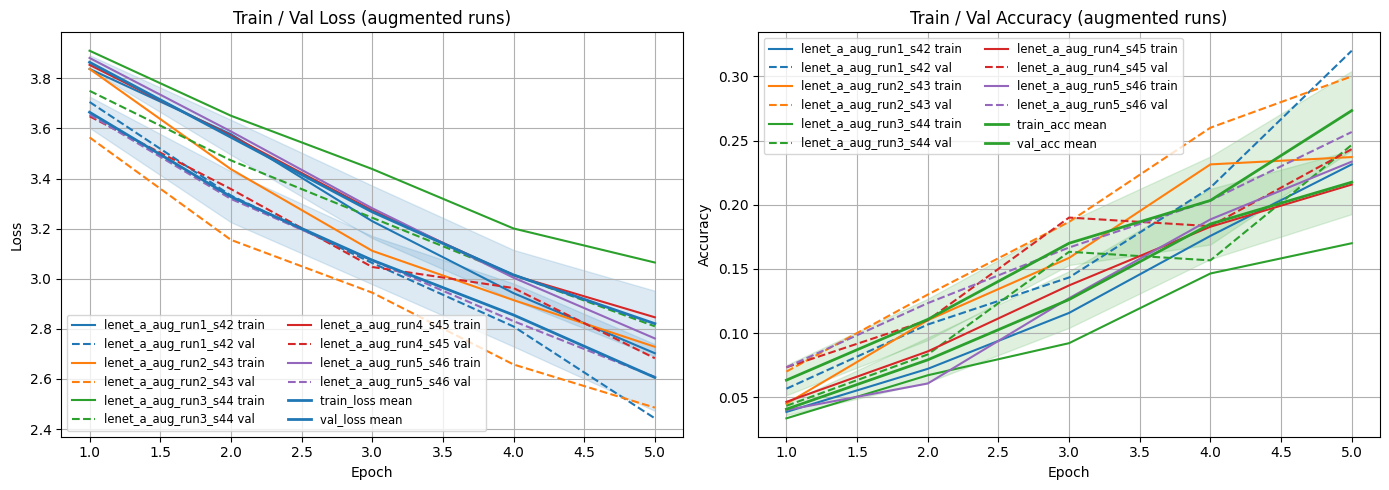

In [22]:
#esta es una sola funcion que recupera info y la plottea

import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
import torch

OUT_DIR = "results_lenet_a_aug"

def load_history_file(path):
    try:
        if path.endswith(".json"):
            with open(path, "r") as f:
                return json.load(f)
        if path.endswith(".npy") or path.endswith(".npz"):
            arr = np.load(path, allow_pickle=True)
            try:
                return arr.tolist()
            except Exception:
                # npz with named arrays
                return {k: arr[k].tolist() for k in arr.files}
        if path.endswith(".pth") or path.endswith(".pt"):
            d = torch.load(path, map_location="cpu")
            if isinstance(d, dict):
                if "history" in d and isinstance(d["history"], dict):
                    return d["history"]
                # sometimes whole run saved as dict
                for k in ("train_loss","val_loss","train_acc","val_acc"):
                    if k in d:
                        return {k: d[k] for k in ("train_loss","val_loss","train_acc","val_acc") if k in d}
    except Exception:
        return None
    return None

def load_histories_from_disk(out_dir):
    histories = {}
    # buscar archivos explícitos llamados *history*
    for p in glob.glob(os.path.join(out_dir, "**", "*history*.*"), recursive=True):
        h = load_history_file(p)
        if isinstance(h, dict) and h:
            histories[os.path.basename(p)] = h
    # buscar checkpoints best_*.pth
    for p in glob.glob(os.path.join(out_dir, "best_*.pth")) + glob.glob(os.path.join(out_dir, "**", "best_*.pth"), recursive=True):
        h = load_history_file(p)
        if isinstance(h, dict) and h:
            histories[os.path.basename(p)] = h
    return histories

# preferir variable en memoria creada por la celda de runs
runs_list = None
if "aggregate_aug" in globals() and isinstance(globals()["aggregate_aug"], list) and globals()["aggregate_aug"]:
    runs_list = globals()["aggregate_aug"]
elif "results" in globals() and isinstance(globals()["results"], list) and globals()["results"]:
    runs_list = globals()["results"]

# si no hay en memoria, intentar cargar desde disco
if runs_list is None:
    loaded = load_histories_from_disk(OUT_DIR)
    if loaded:
        runs_list = []
        for name, h in loaded.items():
            runs_list.append({"run_name": name, "history": h})
    else:
        print("No se encontraron resultados en memoria ni historiales en disco.")
        print("Asegúrate de ejecutar los runs en esta sesión (variable `aggregate_aug` o `results`)")
        print("o guarda la variable 'history' desde run_experiment en archivos '*history*.npy/.json' dentro de", OUT_DIR)
        raise SystemExit

# normalize
normalized = []
for r in runs_list:
    if isinstance(r, dict) and "history" in r:
        h = r["history"]
        name = r.get("run_name", r.get("run_name", "run"))
    elif isinstance(r, dict) and all(k in r for k in ("train_loss","val_loss","train_acc","val_acc")):
        h = {k: r[k] for k in ("train_loss","val_loss","train_acc","val_acc")}
        name = r.get("run_name","run")
    else:
        # intentar interpretar r como history dict
        h = r if isinstance(r, dict) else {}
        name = "run"
    # convertir a np.array y manejar listas vacías
    for k in ("train_loss","val_loss","train_acc","val_acc"):
        if k in h:
            try:
                h[k] = np.array(h[k], dtype=float)
            except Exception:
                # dejar como lista si falla
                h[k] = np.array(list(h[k]), dtype=float) if hasattr(h[k], "__iter__") else np.array([float(h[k])])
    normalized.append({"run_name": name, "history": h})

# preparar figura
plt.rcParams.update({"figure.max_open_warning": 0})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,5))
colors = plt.cm.tab10.colors
same_length = True
lengths = []

for idx, r in enumerate(normalized):
    h = r["history"]
    name = r["run_name"]
    c = colors[idx % len(colors)]
    # Loss
    if "train_loss" in h and "val_loss" in h:
        ax1.plot(np.arange(1, len(h["train_loss"])+1), h["train_loss"], label=f"{name} train", color=c, linestyle='-')
        ax1.plot(np.arange(1, len(h["val_loss"])+1), h["val_loss"], label=f"{name} val", color=c, linestyle='--')
        lengths.append(len(h["train_loss"]))
    else:
        # intentar dibujo parcial si hay alguno de los dos
        if "train_loss" in h:
            ax1.plot(np.arange(1, len(h["train_loss"])+1), h["train_loss"], label=f"{name} train", color=c, linestyle='-')
            lengths.append(len(h["train_loss"]))
        if "val_loss" in h:
            ax1.plot(np.arange(1, len(h["val_loss"])+1), h["val_loss"], label=f"{name} val", color=c, linestyle='--')
            lengths.append(len(h["val_loss"]))
    # Acc
    if "train_acc" in h and "val_acc" in h:
        ax2.plot(np.arange(1, len(h["train_acc"])+1), h["train_acc"], label=f"{name} train", color=c, linestyle='-')
        ax2.plot(np.arange(1, len(h["val_acc"])+1), h["val_acc"], label=f"{name} val", color=c, linestyle='--')
    else:
        if "train_acc" in h:
            ax2.plot(np.arange(1, len(h["train_acc"])+1), h["train_acc"], label=f"{name} train", color=c, linestyle='-')
        if "val_acc" in h:
            ax2.plot(np.arange(1, len(h["val_acc"])+1), h["val_acc"], label=f"{name} val", color=c, linestyle='--')

if len(lengths) > 1 and len(set(lengths)) != 1:
    same_length = False

# si todas las runs tienen la misma longitud, dibujar media +- std
if same_length and lengths:
    L = lengths[0]
    # construir matrices
    def collect(key):
        arrs = []
        for r in normalized:
            h = r["history"]
            if key in h and len(h[key]) == L:
                arrs.append(h[key])
        return np.vstack(arrs) if arrs else None
    for key, ax, ylabel, title in [
        ("train_loss", ax1, "Loss", "Train Loss (runs)"),
        ("val_loss", ax1, "Loss", "Validation Loss (runs)"),
        ("train_acc", ax2, "Accuracy", "Train Acc (runs)"),
        ("val_acc", ax2, "Accuracy", "Val Acc (runs)"),
    ]:
        mat = collect(key)
        if mat is not None and mat.shape[0] >= 2:
            mean = mat.mean(axis=0)
            std = mat.std(axis=0)
            epochs = np.arange(1, L+1)
            # only fill for mean of train/val groups: use linestyle for distinguish
            alpha = 0.15
            if "loss" in key:
                ax.fill_between(epochs, mean-std, mean+std, color='tab:blue', alpha=alpha)
                ax.plot(epochs, mean, color='tab:blue', linewidth=2, label=f"{key} mean")
            else:
                ax.fill_between(epochs, mean-std, mean+std, color='tab:green', alpha=alpha)
                ax.plot(epochs, mean, color='tab:green', linewidth=2, label=f"{key} mean")

ax1.set_title("Train / Val Loss (augmented runs)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)
ax1.legend(fontsize='small', ncol=2)

ax2.set_title("Train / Val Accuracy (augmented runs)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.grid(True)
ax2.legend(fontsize='small', ncol=2)

plt.tight_layout()

# guardar y mostrar
os.makedirs(OUT_DIR, exist_ok=True)
plot_path = os.path.join(OUT_DIR, "plots_augmented_history.png")
fig.savefig(plot_path, dpi=150, bbox_inches='tight')
print("Gráficas guardadas en:", plot_path)
plt.show()